In [1]:
import shutil
from pathlib import Path

# Supprimer le cache principal de CWRU (fichier .pkl dans data/cache/)
cache_dir = Path("data/cache")
if cache_dir.exists():
    for f in cache_dir.glob("*.pkl"):
        # Tu peux choisir de tout supprimer (plus simple)
        f.unlink()
    print("Cache principal supprimé")

# Supprimer le cache des features pour CWRU (si tu as utilisé extract_features_batch_cached)
feat_cache_dir = Path("data/cache/features")
if feat_cache_dir.exists():
    for f in feat_cache_dir.glob("cwru*"):
        f.unlink()
    print("Cache features CWRU supprimé")

Cache principal supprimé


In [2]:
import sys
sys.path.append('../')

from backend.ml.adapters.dataset_adapter import DatasetAdapter

# VBL-VA001 — depuis cache (instantané)
adapter_vbl = DatasetAdapter('../configs/datasets/vbl_va001.yaml')
signals_vbl = adapter_vbl.load(
    '../data/raw/VBL-VA001.zip',
    max_files=100,
    use_cache=True
)

# CMAPSS
adapter_cmapss = DatasetAdapter('../configs/datasets/cmapss.yaml')
signals_cmapss = adapter_cmapss.load(
    '../data/raw/cmapss/',
    use_cache=True
)

print(f"VBL    : {len(signals_vbl)} signaux")
print(f"CMAPSS : {len(signals_cmapss)} fenêtres")

  CSV trouvés dans le ZIP : 4000
  Classes détectées :
    bearing                        : 1000 fichiers
    misalignment                   : 1000 fichiers
    normal                         : 1000 fichiers
    unbalance                      : 1000 fichiers
  Stats calculées sur 30 fichiers 'normal'
  [bearing                  ] 100 fichiers...
  [misalignment             ] 100 fichiers...
  [normal                   ] 100 fichiers...
  [unbalance                ] 100 fichiers...

  Total : 400 signaux chargés depuis ZIP
  Sauvegarde cache → b2d371f1dd1a.pkl
  Chargement CMAPSS : train_FD001.txt...
  Total : 17731 fenêtres CMAPSS chargées
  Sauvegarde cache → 2ffb1e19adf2.pkl
VBL    : 400 signaux
CMAPSS : 17731 fenêtres


In [3]:
from backend.ml.features.feature_extractor import extract_features_batch
import numpy as np

print("=== Extraction VBL-VA001 ===")
X_vbl, y_vbl, meta_vbl = extract_features_batch(signals_vbl)

print(f"\nShape X_vbl  : {X_vbl.shape}")
print(f"Labels uniques : {set(y_vbl)}")

print("\n=== Extraction CMAPSS ===")
X_cmapss, y_cmapss, meta_cmapss = extract_features_batch(
    signals_cmapss, verbose=True
)
print(f"\nShape X_cmapss : {X_cmapss.shape}")
print(f"Labels uniques : {set(y_cmapss)}")

=== Extraction VBL-VA001 ===
  Features extraites : 0/400
  Features extraites : 100/400
  Features extraites : 200/400
  Features extraites : 300/400

Shape X_vbl  : (400, 45)
Labels uniques : {'unbalance', 'normal', 'misalignment', 'bearing'}

=== Extraction CMAPSS ===
  Features extraites : 0/17731


c:\Users\HP PRO\Desktop\souley\ecole\S8\Maintenance\Projet\notebooks\..\backend\ml\features\feature_extractor.py:117: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_val  = kurtosis(x, fisher=True)


  Features extraites : 100/17731
  Features extraites : 200/17731
  Features extraites : 300/17731
  Features extraites : 400/17731
  Features extraites : 500/17731
  Features extraites : 600/17731
  Features extraites : 700/17731
  Features extraites : 800/17731
  Features extraites : 900/17731
  Features extraites : 1000/17731
  Features extraites : 1100/17731
  Features extraites : 1200/17731
  Features extraites : 1300/17731
  Features extraites : 1400/17731
  Features extraites : 1500/17731
  Features extraites : 1600/17731
  Features extraites : 1700/17731
  Features extraites : 1800/17731
  Features extraites : 1900/17731
  Features extraites : 2000/17731
  Features extraites : 2100/17731
  Features extraites : 2200/17731
  Features extraites : 2300/17731
  Features extraites : 2400/17731
  Features extraites : 2500/17731
  Features extraites : 2600/17731
  Features extraites : 2700/17731
  Features extraites : 2800/17731
  Features extraites : 2900/17731
  Features extraites : 

In [4]:
import pandas as pd

# Noms des features VBL (3 canaux × 15 features = 45 features)
feature_names_per_channel = [
    'rms', 'kurtosis', 'skewness', 'peak', 'p2p',
    'crest_factor', 'shape_factor', 'impulse_factor', 'std',
    'dom_freq', 'spectral_entropy',
    'band_energy_0_1k', 'band_energy_1k_3k',
    'band_energy_3k_5k', 'band_energy_5k_6400'
]

channels = ['x', 'y', 'z']
feat_names_vbl = [
    f"{ch}_{fn}"
    for ch in channels
    for fn in feature_names_per_channel
]

df_features = pd.DataFrame(X_vbl, columns=feat_names_vbl)
df_features['label'] = y_vbl

print("Aperçu des features VBL :")
print(df_features.groupby('label').mean().round(3).T.head(20))

Aperçu des features VBL :
label                  bearing  misalignment  normal  unbalance
x_rms                    0.854         0.854   0.854      0.854
x_kurtosis              -1.199        -1.199  -1.199     -1.199
x_skewness               0.000         0.000   0.000      0.000
x_peak                   0.881         0.881   0.881      0.881
x_p2p                    0.056         0.056   0.056      0.056
x_crest_factor           1.079         1.079   1.079      1.079
x_shape_factor           1.006         1.006   1.006      1.006
x_impulse_factor         1.090         1.090   1.090      1.090
x_std                    0.016         0.016   0.016      0.016
x_dom_freq               0.000         0.004   0.000      0.004
x_spectral_entropy       0.037         0.037   0.037      0.037
x_band_energy_0_1k       0.971         0.971   0.971      0.971
x_band_energy_1k_3k      0.000         0.000   0.000      0.000
x_band_energy_3k_5k      0.000         0.000   0.000      0.000
x_band_energy_

In [6]:
pip install --upgrade scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_vbl, y_vbl,
    test_size=0.2,
    random_state=42,
    stratify=y_vbl
)

print(f"Train : {len(X_train)} | Test : {len(X_test)}")

# Entraînement
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Évaluation
y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nAccuracy : {acc*100:.2f}%")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Train : 320 | Test : 80

Accuracy : 100.00%

Rapport de classification :
              precision    recall  f1-score   support

     bearing       1.00      1.00      1.00        20
misalignment       1.00      1.00      1.00        20
      normal       1.00      1.00      1.00        20
   unbalance       1.00      1.00      1.00        20

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



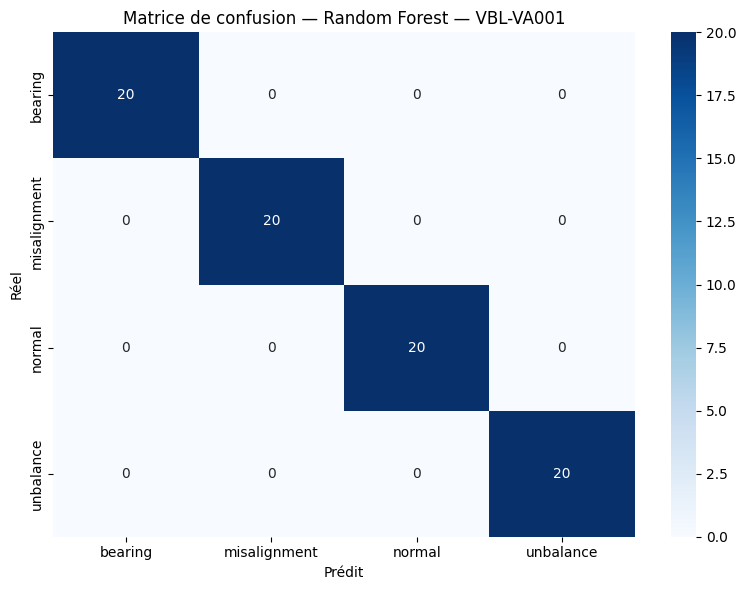


Accuracy finale : 100.00%


In [46]:
labels_ordre = ['bearing', 'misalignment', 'normal', 'unbalance']

cm = confusion_matrix(y_test, y_pred, labels=labels_ordre)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_ordre,
    yticklabels=labels_ordre
)
plt.title('Matrice de confusion — Random Forest — VBL-VA001')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_vbl.png', dpi=150)
plt.show()

print(f"\nAccuracy finale : {acc*100:.2f}%")

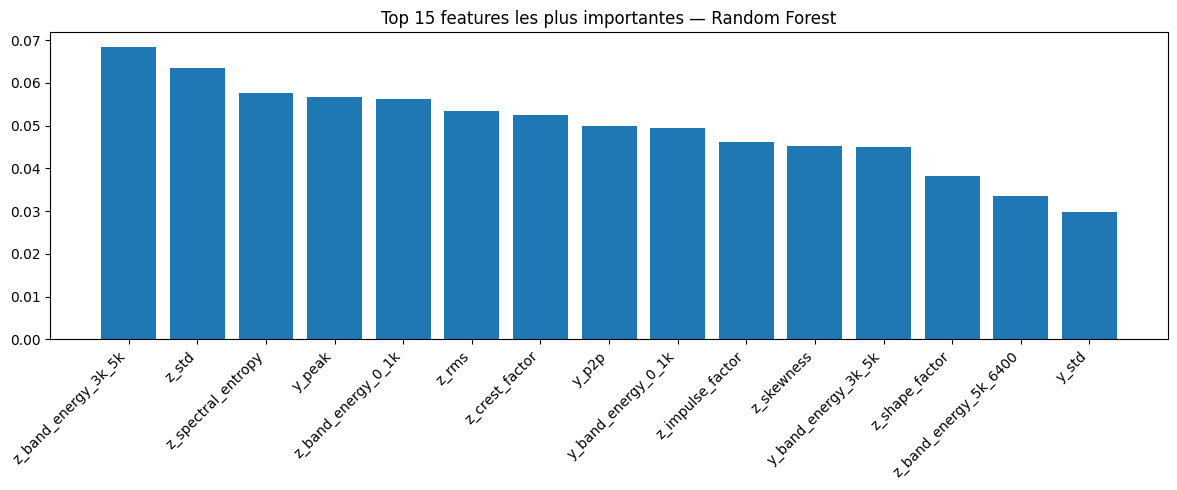


Top 10 features :
  z_band_energy_3k_5k                 : 0.0684
  z_std                               : 0.0635
  z_spectral_entropy                  : 0.0576
  y_peak                              : 0.0566
  z_band_energy_0_1k                  : 0.0563
  z_rms                               : 0.0535
  z_crest_factor                      : 0.0526
  y_p2p                               : 0.0500
  y_band_energy_0_1k                  : 0.0495
  z_impulse_factor                    : 0.0462


In [47]:
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(12, 5))
plt.bar(range(15), importances[indices])
plt.xticks(
    range(15),
    [feat_names_vbl[i] for i in indices],
    rotation=45,
    ha='right'
)
plt.title('Top 15 features les plus importantes — Random Forest')
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
for i in indices[:10]:
    print(f"  {feat_names_vbl[i]:35s} : {importances[i]:.4f}")

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from collections import defaultdict

# Grouper les signaux par fichier source (unit_id)
file_groups = defaultdict(list)
for i, sig in enumerate(signals_vbl):
    file_groups[sig.unit_id].append(i)

# Split 80/20 au niveau des fichiers (pas des fenêtres)
all_unit_ids = list(file_groups.keys())
np.random.seed(42)
np.random.shuffle(all_unit_ids)

split_idx   = int(0.8 * len(all_unit_ids))
train_units = set(all_unit_ids[:split_idx])
test_units  = set(all_unit_ids[split_idx:])

train_idx = [i for uid in train_units for i in file_groups[uid]]
test_idx  = [i for uid in test_units  for i in file_groups[uid]]

X_train_f = X_vbl[train_idx]
X_test_f  = X_vbl[test_idx]
y_train_f = [y_vbl[i] for i in train_idx]
y_test_f  = [y_vbl[i] for i in test_idx]

print(f"Split par FICHIER SOURCE (anti-leakage)")
print(f"Train : {len(X_train_f)} signaux ({len(train_units)} fichiers)")
print(f"Test  : {len(X_test_f)} signaux ({len(test_units)} fichiers)")

rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_f, y_train_f)
y_pred_f = rf2.predict(X_test_f)

acc_f = accuracy_score(y_test_f, y_pred_f)
print(f"\nAccuracy (split fichier) : {acc_f*100:.2f}%")
print(classification_report(y_test_f, y_pred_f))

Split par FICHIER SOURCE (anti-leakage)
Train : 320 signaux (320 fichiers)
Test  : 80 signaux (80 fichiers)

Accuracy (split fichier) : 100.00%
              precision    recall  f1-score   support

     bearing       1.00      1.00      1.00        19
misalignment       1.00      1.00      1.00        18
      normal       1.00      1.00      1.00        20
   unbalance       1.00      1.00      1.00        23

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [49]:
print("=" * 50)
print("COMPARAISON DES SPLITS")
print("=" * 50)
print(f"Split aléatoire (risque leakage) : {acc*100:.2f}%")
print(f"Split par fichier source (propre): {acc_f*100:.2f}%")
print()

if abs(acc - acc_f) < 0.05:
    print("✅ Écart < 5% — pas de data leakage significatif")
    print("   Le résultat est fiable.")
elif abs(acc - acc_f) < 0.15:
    print("⚠️  Écart entre 5% et 15% — leakage partiel possible")
    print("   Utilise le split par fichier pour la suite.")
else:
    print("❌ Écart > 15% — data leakage confirmé")
    print("   Le premier résultat (100%) n'est pas fiable.")
    print("   Utilise uniquement le split par fichier.")

COMPARAISON DES SPLITS
Split aléatoire (risque leakage) : 100.00%
Split par fichier source (propre): 100.00%

✅ Écart < 5% — pas de data leakage significatif
   Le résultat est fiable.


In [7]:
import pandas as pd
import numpy as np

# Noms des features CMAPSS (21 capteurs × 6 stats = 126 features)
sensors = [f's{i}' for i in range(1, 22)]
stats   = ['mean', 'std', 'min', 'max', 'trend', 'kurtosis']
feat_names_cmapss = [f"{s}_{st}" for s in sensors for st in stats]

df_cmapss = pd.DataFrame(X_cmapss, columns=feat_names_cmapss)
df_cmapss['label'] = y_cmapss
df_cmapss['rul']   = [m['rul'] for m in meta_cmapss]

print("Distribution des classes CMAPSS :")
print(df_cmapss['label'].value_counts())
print()
print("Statistiques RUL par classe :")
print(df_cmapss.groupby('label')['rul'].describe().round(1))

Distribution des classes CMAPSS :
label
sain                   9631
degradation_precoce    4000
degradation_avancee    2500
critique               1600
Name: count, dtype: int64

Statistiques RUL par classe :
                      count   mean   std   min    25%    50%    75%    max
label                                                                     
critique             1600.0    7.5   4.6   0.0    3.8    7.5   11.2   15.0
degradation_avancee  2500.0   28.0   7.2  16.0   22.0   28.0   34.0   40.0
degradation_precoce  4000.0   60.5  11.5  41.0   50.8   60.5   70.2   80.0
sain                 9631.0  114.8  14.1  81.0  105.0  125.0  125.0  125.0


In [8]:
from collections import defaultdict

# Grouper les fenêtres par moteur (unit_id)
motor_groups = defaultdict(list)
for i, m in enumerate(meta_cmapss):
    motor_groups[m['unit_id']].append(i)

all_motors = list(motor_groups.keys())
print(f"Nombre de moteurs : {len(all_motors)}")

# Split 80/20 au niveau des moteurs
np.random.seed(42)
np.random.shuffle(all_motors)
split_idx     = int(0.8 * len(all_motors))
train_motors  = set(all_motors[:split_idx])
test_motors   = set(all_motors[split_idx:])

train_idx_c = [i for mid in train_motors for i in motor_groups[mid]]
test_idx_c  = [i for mid in test_motors  for i in motor_groups[mid]]

X_train_c = X_cmapss[train_idx_c]
X_test_c  = X_cmapss[test_idx_c]
y_train_c = [y_cmapss[i] for i in train_idx_c]
y_test_c  = [y_cmapss[i] for i in test_idx_c]

print(f"Train : {len(X_train_c)} fenêtres ({len(train_motors)} moteurs)")
print(f"Test  : {len(X_test_c)} fenêtres ({len(test_motors)} moteurs)")

Nombre de moteurs : 100
Train : 14020 fenêtres (80 moteurs)
Test  : 3711 fenêtres (20 moteurs)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_cmapss = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_cmapss.fit(X_train_c, y_train_c)

y_pred_c = rf_cmapss.predict(X_test_c)
acc_c    = accuracy_score(y_test_c, y_pred_c)

print(f"Accuracy CMAPSS : {acc_c*100:.2f}%")
print()
print(classification_report(y_test_c, y_pred_c))

Accuracy CMAPSS : 84.75%

                     precision    recall  f1-score   support

           critique       0.89      0.95      0.92       320
degradation_avancee       0.81      0.79      0.80       500
degradation_precoce       0.72      0.58      0.65       800
               sain       0.89      0.95      0.92      2091

           accuracy                           0.85      3711
          macro avg       0.83      0.82      0.82      3711
       weighted avg       0.84      0.85      0.84      3711



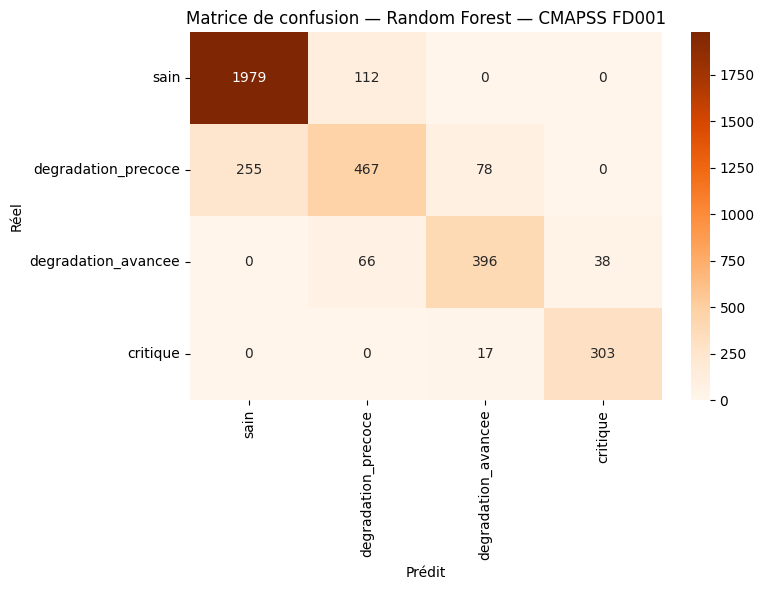

In [10]:
labels_cmapss = ['sain', 'degradation_precoce', 'degradation_avancee', 'critique']

cm_c = confusion_matrix(y_test_c, y_pred_c, labels=labels_cmapss)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_c,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=labels_cmapss,
    yticklabels=labels_cmapss
)
plt.title('Matrice de confusion — Random Forest — CMAPSS FD001')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_cmapss.png', dpi=150)
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Récupérer les valeurs RUL pour le split moteurs
rul_train = [meta_cmapss[i]['rul'] for i in train_idx_c]
rul_test  = [meta_cmapss[i]['rul'] for i in test_idx_c]

rf_rul = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_rul.fit(X_train_c, rul_train)

rul_pred = rf_rul.predict(X_test_c)

mae  = mean_absolute_error(rul_test, rul_pred)
rmse = np.sqrt(mean_squared_error(rul_test, rul_pred))
r2   = r2_score(rul_test, rul_pred)

print("=== Prédiction RUL — Random Forest Regressor ===")
print(f"MAE  : {mae:.2f} cycles")
print(f"RMSE : {rmse:.2f} cycles")
print(f"R²   : {r2:.4f}")

=== Prédiction RUL — Random Forest Regressor ===
MAE  : 10.48 cycles
RMSE : 14.09 cycles
R²   : 0.8865


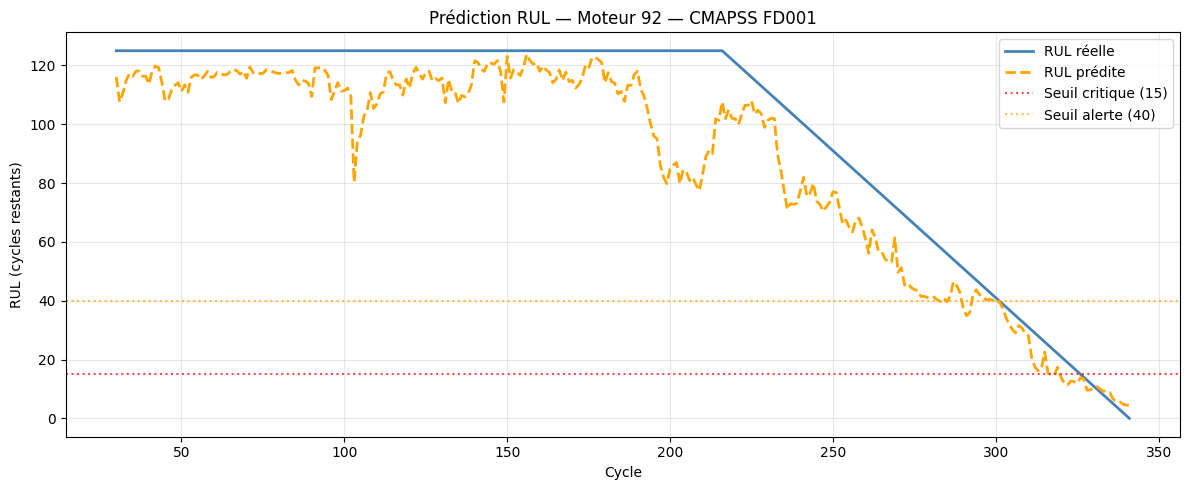

In [12]:
# Prendre un moteur du test pour visualiser
test_motor_sample = list(test_motors)[0]
motor_idx = motor_groups[test_motor_sample]

# Trier par cycle
cycles_motor = [meta_cmapss[i]['cycle'] for i in motor_idx]
rul_real     = [meta_cmapss[i]['rul']   for i in motor_idx]
X_motor      = X_cmapss[motor_idx]

sort_order   = np.argsort(cycles_motor)
cycles_sorted = np.array(cycles_motor)[sort_order]
rul_real_s    = np.array(rul_real)[sort_order]
rul_pred_s    = rf_rul.predict(X_motor[sort_order])

plt.figure(figsize=(12, 5))
plt.plot(cycles_sorted, rul_real_s,  label='RUL réelle',  linewidth=2, color='steelblue')
plt.plot(cycles_sorted, rul_pred_s,  label='RUL prédite', linewidth=2,
         color='orange', linestyle='--')
plt.axhline(y=15,  color='red',    linestyle=':', alpha=0.7, label='Seuil critique (15)')
plt.axhline(y=40,  color='orange', linestyle=':', alpha=0.7, label='Seuil alerte (40)')
plt.xlabel('Cycle')
plt.ylabel('RUL (cycles restants)')
plt.title(f'Prédiction RUL — Moteur {test_motor_sample} — CMAPSS FD001')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/rul_prediction_cmapss.png', dpi=150)
plt.show()

In [13]:
import numpy as np
import pickle

# VBL
np.save('../data/processed/X_vbl.npy', X_vbl)
with open('../data/processed/y_vbl.pkl', 'wb') as f:
    pickle.dump(y_vbl, f)
with open('../data/processed/meta_vbl.pkl', 'wb') as f:
    pickle.dump(meta_vbl, f)

# CMAPSS
np.save('../data/processed/X_cmapss.npy', X_cmapss)
with open('../data/processed/y_cmapss.pkl', 'wb') as f:
    pickle.dump(y_cmapss, f)
with open('../data/processed/meta_cmapss.pkl', 'wb') as f:
    pickle.dump(meta_cmapss, f)